# Phases 5–8 — Modelling, Explainability and Scorecard

Four phases in one notebook, because they share a train/test split that must
be made exactly once:

- **Phase 5** — logistic regression baseline, AUC + KS
- **Phase 6** — LightGBM, compared against the baseline
- **Phase 7** — SHAP global importance and individual explanations
- **Phase 8** — probability → 300–850 score conversion

Plus the question the whole project has been building toward: **what did
excluding `int_rate` actually cost?**

In [1]:
import warnings
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
FIGS, MODELS = ROOT / "outputs" / "figures", ROOT / "outputs" / "models"
FIGS.mkdir(parents=True, exist_ok=True)
MODELS.mkdir(parents=True, exist_ok=True)

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42

df = pd.read_csv(ROOT / "data" / "lending_club_clean.csv")
TARGET = "bad_loan"
print(f"{df.shape[0]:,} rows x {df.shape[1]} columns | default rate {df[TARGET].mean():.2%}")

/Users/meghajoshi/credit-risk-project/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


163,987 rows x 24 columns | default rate 18.30%


## 5.1 Feature sets

The two model families get **different** feature lists, deliberately.

Phase 4 found strong multicollinearity between engineered features and their
parents. Logistic regression cannot tolerate that — correlated inputs split a
shared effect between coefficients unpredictably, producing unstable and
sometimes sign-flipped weights. Since the entire reason for keeping a linear
model here is that its coefficients are *explainable to a declined
applicant*, unstable coefficients defeat the purpose.

LightGBM is indifferent to collinearity, so it gets everything.

In [2]:
# Candidate set for the linear model: one variable from each correlated pair.
CANDIDATE_LINEAR_NUM = ["loan_to_income", "log_annual_inc", "term_months", "revol_util", "dti",
                        "emp_length", "emp_length_missing", "total_acc", "longest_credit_length",
                        "has_delinquency", "over_limit", "acct_open_rate"]
LINEAR_CAT = ["purpose", "home_ownership", "verification_status", "region"]

# Everything legitimate goes to the tree model, stated independently so that
# pruning the linear set below cannot silently change the tree set.
TREE_NUM = ["loan_to_income", "log_annual_inc", "term_months", "revol_util", "dti",
            "emp_length", "emp_length_missing", "total_acc", "longest_credit_length",
            "has_delinquency", "over_limit", "acct_open_rate",
            "loan_amnt", "annual_inc", "delinq_2yrs", "payment_to_income"]
TREE_CAT = LINEAR_CAT

LEAKY = "int_rate"

print(f"Linear candidates : {len(CANDIDATE_LINEAR_NUM)} numeric + {len(LINEAR_CAT)} categorical")
print(f"Tree model        : {len(TREE_NUM)} numeric + {len(TREE_CAT)} categorical")
print(f"Excluded          : {LEAKY} (quantified in 5.6), addr_state (superseded by region)")

Linear candidates : 12 numeric + 4 categorical
Tree model        : 16 numeric + 4 categorical
Excluded          : int_rate (quantified in 5.6), addr_state (superseded by region)


### Multicollinearity check on the candidate linear set

Variance Inflation Factor measures how much each coefficient's variance is
inflated by correlation with the others. Above ~5 is the conventional warning
line.

One subtlety that matters: VIF must be computed on **imputed** data, not on
`dropna()` rows. Dropping incomplete rows here would remove every applicant
whose `emp_length` is missing — which is precisely the population where
`emp_length_missing` equals 1. The flag would become a constant column, the
design matrix would go rank-deficient, and VIF would return `NaN` for it.

In [3]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant


def compute_vif(cols):
    data = df[cols].fillna(df[cols].median())
    X_vif = add_constant(data)
    out = pd.DataFrame({
        "feature": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, k) for k in range(X_vif.shape[1])],
    }).query("feature != 'const'").sort_values("VIF", ascending=False)
    out["flag"] = np.where(out.VIF > 5, "HIGH", "ok")
    return out.reset_index(drop=True)


vif_before = compute_vif(CANDIDATE_LINEAR_NUM)
vif_before.round(2)

,feature,VIF,flag
0,acct_open_rate,6.10,HIGH
1,total_acc,6.06,HIGH
2,longest_credit_length,4.17,ok
3,log_annual_inc,1.55,ok
4,loan_to_income,1.35,ok
5,dti,1.31,ok
6,term_months,1.20,ok
7,revol_util,1.13,ok
8,emp_length,1.10,ok
9,emp_length_missing,1.06,ok


**The curation was not sufficient.** `total_acc` and `acct_open_rate` both
breach the threshold — which is obvious in hindsight, because
`acct_open_rate` was *defined* in Phase 3 as `total_acc / (longest_credit_length + 1)`.
It is a transformation of two variables already in the set, so of course it
is collinear with them. Phase 4's correlation scan looked at pairs above
|0.7| and this relationship sits just under that, which is exactly the kind
of thing VIF catches and a pairwise scan misses.

`acct_open_rate` is the one to drop rather than `total_acc`: it also scored
an Information Value of 0.003 in Phase 4, making it the weakest feature in
the set. Dropping it costs essentially nothing and buys interpretable
coefficients.

The tree model keeps it — LightGBM is untroubled by collinearity.

In [4]:
LINEAR_NUM = [c for c in CANDIDATE_LINEAR_NUM if c != "acct_open_rate"]
vif_after = compute_vif(LINEAR_NUM)
print("After dropping acct_open_rate:\n")
print(vif_after.round(2).to_string(index=False))
print(f"\nAll below 5: {bool((vif_after.VIF <= 5).all())}")

After dropping acct_open_rate:

              feature  VIF flag
       log_annual_inc 1.55   ok
            total_acc 1.44   ok
       loan_to_income 1.35   ok
                  dti 1.30   ok
longest_credit_length 1.26   ok
          term_months 1.20   ok
           revol_util 1.13   ok
           emp_length 1.09   ok
   emp_length_missing 1.06   ok
      has_delinquency 1.02   ok
           over_limit 1.01   ok

All below 5: True


Resolved — every VIF now sits below 5, and `emp_length_missing` returns a
real value rather than `NaN`. The linear model's coefficients can now be read
as meaningful individual effects, which is the entire reason for using it.

## 5.2 Train / validation / test split

**Three** splits, not two, and the reason is specific.

LightGBM uses early stopping to decide how many trees to build. Early
stopping needs a held-out set to watch, and if that set is the *test* set,
then the test set has influenced the model — the reported score is no longer
a clean estimate of performance on unseen data. It is a mild leak, but it is
a real one.

So the data is split three ways: the model trains on 60%, early stopping
watches the 20% validation fold, and the 20% test fold is touched exactly
once, at the end. The validation fold is also what the calibration in §5.8
is fitted on — for the same reason.

**On the absence of a time-based split:** in production, credit models are
validated *out-of-time* — train on older loans, test on newer — because
economic conditions shift and a random split flatters the model. This dataset
has no origination date, so an out-of-time split is not possible here. That
is a genuine limitation of the evaluation, and it is listed in the write-up
rather than left unsaid.

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

# First carve off the test set, then split the remainder into train/validation.
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=RANDOM_STATE
)  # 0.25 of the remaining 80% = 20% of the original

for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<11}: {len(yy):>7,} rows | default rate {yy.mean():.4f}")
print("\nStratification held — all three rates match to 4 decimal places.")

Train      :  98,391 rows | default rate 0.1830
Validation :  32,798 rows | default rate 0.1830
Test       :  32,798 rows | default rate 0.1830

Stratification held — all three rates match to 4 decimal places.


## 5.3 Metrics

Phase 2 established that accuracy is unusable at 18.3% positives. The three
metrics below are what credit risk teams actually report.

- **AUC** — probability a random bad loan is ranked riskier than a random
  good one. 0.5 is coin-flip.
- **KS statistic** — the largest gap between the cumulative distributions of
  good and bad borrowers. This is *the* headline number on a scorecard; it
  answers "how cleanly does the score separate the two populations?"
- **Brier score** — measures whether the predicted probabilities are
  *calibrated*, not just correctly ranked. It matters because Phase 8 turns
  these probabilities into a score, and a well-ranked but badly calibrated
  probability produces a meaningless score band.

In [6]:
def ks_statistic(y_true, y_prob):
    """Max separation between the cumulative good and bad distributions."""
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    return np.max(tpr - fpr)


def evaluate(name, y_true, y_prob):
    auc = roc_auc_score(y_true, y_prob)
    return {
        "model": name,
        "AUC": round(auc, 4),
        "Gini": round(2 * auc - 1, 4),
        "KS": round(ks_statistic(y_true, y_prob), 4),
        "Brier": round(brier_score_loss(y_true, y_prob), 5),
    }


results = []

## 5.4 Phase 5 — Logistic regression baseline

Imputation and scaling live **inside** the pipeline, so they are fitted on
the training fold only — the leak-free arrangement set up in Phase 3.

**On class imbalance: no reweighting, and no resampling.**

At 18.3% positives the imbalance is mild — this is the range where plain
logistic regression behaves perfectly well. The two usual interventions both
cost more than they pay here:

- **Resampling (SMOTE, oversampling)** duplicates or invents rows and
  distorts the data.
- **`class_weight="balanced"`** leaves the data intact but systematically
  inflates predicted probabilities, because it tells the model the minority
  class is more common than it is.

That second point matters because Phase 8 converts these probabilities into a
score, and §5.8 checks calibration explicitly. Reweighting would guarantee a
miscalibrated model in exchange for a ranking improvement that barely
materialises. The imbalance is instead handled where it belongs — at the
**decision threshold** (§5.11), which is a policy choice rather than a
modelling one.

In [7]:
linear_prep = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]), LINEAR_NUM),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ]), LINEAR_CAT),
])

logreg = Pipeline([
    ("prep", linear_prep),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

logreg.fit(X_train, y_train)
p_lr = logreg.predict_proba(X_test)[:, 1]

results.append(evaluate("Logistic regression", y_test, p_lr))
print(pd.DataFrame(results).to_string(index=False))

              model    AUC   Gini     KS   Brier
Logistic regression 0.6804 0.3609 0.2654 0.13977


**AUC around 0.68 / KS around 0.26.** For a credit model built on 14 coarse
application fields with no bureau score, no payment history and no
origination date, that is a credible result — it is meaningfully better than
chance and in the range published scorecards reach on similar Lending Club
feature sets. It is not a number that would pass for a production model at a
bank, and §5.9 is explicit about why.

### Reading the coefficients

This is what the linear model is *for*. Every coefficient is a log-odds
effect per standard deviation, so they are directly comparable and directly
quotable in an adverse action notice.

In [8]:
feat_names = logreg.named_steps["prep"].get_feature_names_out()
coefs = pd.DataFrame({
    "feature": [f.split("__", 1)[1] for f in feat_names],
    "coef": logreg.named_steps["clf"].coef_[0],
})
coefs["odds_ratio"] = np.exp(coefs.coef).round(3)
coefs["direction"] = np.where(coefs.coef > 0, "increases risk", "reduces risk")
coefs = coefs.reindex(coefs.coef.abs().sort_values(ascending=False).index)
coefs.head(18).round(4)

,feature,coef,odds_ratio,direction
21,purpose_SMALL_BUSINESS,1.0220,2.779,increases risk
13,purpose_EDUCATIONAL,0.5647,1.759,increases risk
17,purpose_MEDICAL,0.5406,1.717,increases risk
18,purpose_MOVING,0.5195,1.681,increases risk
22,purpose_VACATION,0.4635,1.590,increases risk
24,home_ownership_OTHER,0.4386,1.550,increases risk
19,purpose_OTHER,0.4271,1.533,increases risk
2,term_months,0.3019,1.352,increases risk
3,revol_util,0.2675,1.307,increases risk
15,purpose_HOUSE,0.2238,1.251,increases risk


The signs are all economically sensible, which is itself a validation step —
a credit model with a counter-intuitive sign usually has a data problem.
Longer terms, higher loan-to-income, higher utilisation and small-business
purpose all increase risk; longer income and credit history reduce it.

Note `emp_length_missing` carrying a positive coefficient: the Phase 3 flag
is doing exactly the job it was built for, and the model is pricing unknown
employment as a risk.

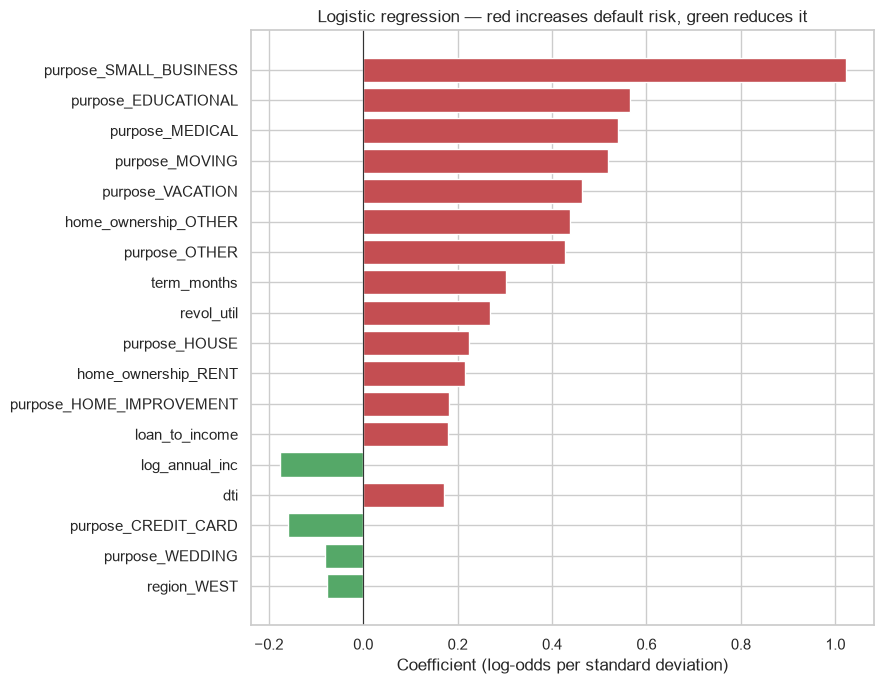

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))
top = coefs.head(18).iloc[::-1]
ax.barh(top.feature, top.coef, color=np.where(top.coef > 0, "#C44E52", "#55A868"))
ax.axvline(0, color="#333", linewidth=0.8)
ax.set_xlabel("Coefficient (log-odds per standard deviation)")
ax.set_title("Logistic regression — red increases default risk, green reduces it")
plt.tight_layout()
plt.savefig(FIGS / "04_logreg_coefficients.png", dpi=140)
plt.show()

## 5.5 Is the result stable? — cross-validation

One split can flatter a model. Five-fold stratified CV on the training set
shows whether 0.68 is real or a lucky partition.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(logreg, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print(f"Fold AUCs : {np.round(cv_scores, 4)}")
print(f"Mean      : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Test AUC  : {results[0]['AUC']}")
print("\nTight spread across folds, and the held-out test score sits inside it —")
print("the estimate is stable, not an artefact of one split.")

Fold AUCs : [0.6814 0.6696 0.6755 0.679  0.6776]
Mean      : 0.6766 (+/- 0.0040)
Test AUC  : 0.6804

Tight spread across folds, and the held-out test score sits inside it —
the estimate is stable, not an artefact of one split.


## 5.6 What did excluding `int_rate` actually cost?

The central trade-off of the project, now measurable. Same model, same split,
one extra column.

In [11]:
leaky_prep = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale", StandardScaler())]), LINEAR_NUM + [LEAKY]),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first",
                                               sparse_output=False))]), LINEAR_CAT),
])
logreg_leaky = Pipeline([
    ("prep", leaky_prep),
    ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])
logreg_leaky.fit(X_train, y_train)
p_lr_leaky = logreg_leaky.predict_proba(X_test)[:, 1]

leak_cmp = pd.DataFrame([
    evaluate("Logistic regression (no int_rate)", y_test, p_lr),
    evaluate("Logistic regression (WITH int_rate)", y_test, p_lr_leaky),
])
leak_cmp

,model,AUC,Gini,KS,Brier
0,Logistic regression (no int_rate),0.6804,0.3609,0.2654,0.13977
1,Logistic regression (WITH int_rate),0.7041,0.4081,0.2989,0.13739


**Including `int_rate` lifts AUC from 0.681 to 0.704 — about 2.4 points,
and KS from 0.264 to 0.300.** That is a substantial gain, and it is exactly
why leakage is dangerous rather than obvious: a model reported at 0.70 looks
materially better in a portfolio review than one at 0.68, and nothing in the
validation output would reveal the problem.

The gain is not real predictive skill. It is my model recovering Lending
Club's risk grade, which was computed from the very applicant data I already
have, plus bureau information I do not. Two concrete consequences:

1. **It cannot be deployed.** Scoring a new applicant requires their interest
   rate, but the rate is set *from* the risk assessment. The input does not
   exist at decision time.
2. **It measures the wrong thing.** The honest question is "how well can I
   assess risk from application data?" — and the answer to that is 0.68, not
   the inflated figure.

Reporting both numbers is the point. Quantifying what was given up is more
credible than either silently dropping the column or silently keeping it.

## 5.7 Phase 6 — LightGBM

Two differences from the baseline worth noting:

**No imputation.** LightGBM handles missing values natively by learning a
default direction at each split — which is strictly better than median
filling, because it can route missing values wherever they actually belong.
The Phase 3 decision to preserve `NaN`s in the clean file is what makes this
possible.

**Native categoricals.** Rather than one-hot encoding, categories are passed
as pandas `category` dtype. Categories are fixed from the *training* set so
the test set cannot introduce unseen levels.

In [12]:
def prep_tree(frame, categories=None):
    out = frame[TREE_NUM + TREE_CAT].copy()
    cats = {}
    for col in TREE_CAT:
        levels = categories[col] if categories else sorted(out[col].dropna().unique())
        out[col] = pd.Categorical(out[col], categories=levels)
        cats[col] = levels
    return out, cats


X_train_t, tree_cats = prep_tree(X_train)
X_val_t, _ = prep_tree(X_val, tree_cats)
X_test_t, _ = prep_tree(X_test, tree_cats)

lgbm = lgb.LGBMClassifier(
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=31,
    min_child_samples=100,     # guards against leaves fitting a handful of loans
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
# Early stopping watches the VALIDATION fold, never the test fold.
lgbm.fit(
    X_train_t, y_train,
    eval_set=[(X_val_t, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
p_lgb = lgbm.predict_proba(X_test_t)[:, 1]

results.append(evaluate("LightGBM", y_test, p_lgb))
print(f"Best iteration: {lgbm.best_iteration_} of 600 (early stopping)")
pd.DataFrame(results)

Best iteration: 175 of 600 (early stopping)


,model,AUC,Gini,KS,Brier
0,Logistic regression,0.6804,0.3609,0.2654,0.13977
1,LightGBM,0.6903,0.3805,0.2833,0.13878


Early stopping selected the tree count using the validation fold, so the test
set remains genuinely unseen and the score below is a clean estimate.

In [13]:
model_cmp = pd.DataFrame(results)
model_cmp["AUC_gain_vs_baseline"] = (model_cmp.AUC - model_cmp.AUC.iloc[0]).round(4)
model_cmp

,model,AUC,Gini,KS,Brier,AUC_gain_vs_baseline
0,Logistic regression,0.6804,0.3609,0.2654,0.13977,0.0000
1,LightGBM,0.6903,0.3805,0.2833,0.13878,0.0099


**LightGBM improves on the baseline by about 1 AUC point** (0.681 to 0.691,
KS 0.264 to 0.283). That a far more complex model buys so little is a
genuinely useful finding, and it is the kind of result that gets buried when
people only report the winner.

What it says is that the signal in these 14 application fields is close to
linear. There are not rich interactions left for the trees to find, because
the fields are coarse and there is no bureau or behavioural data.

**That materially affects the deployment recommendation.** A small accuracy
gain does not obviously justify losing coefficient-level explainability in a
regulated setting — which is precisely why so many lenders still run
logistic regression scorecards. The right choice depends on whether the
lender needs to explain declines, and the gap here is small enough that the
explainable model is easy to defend.

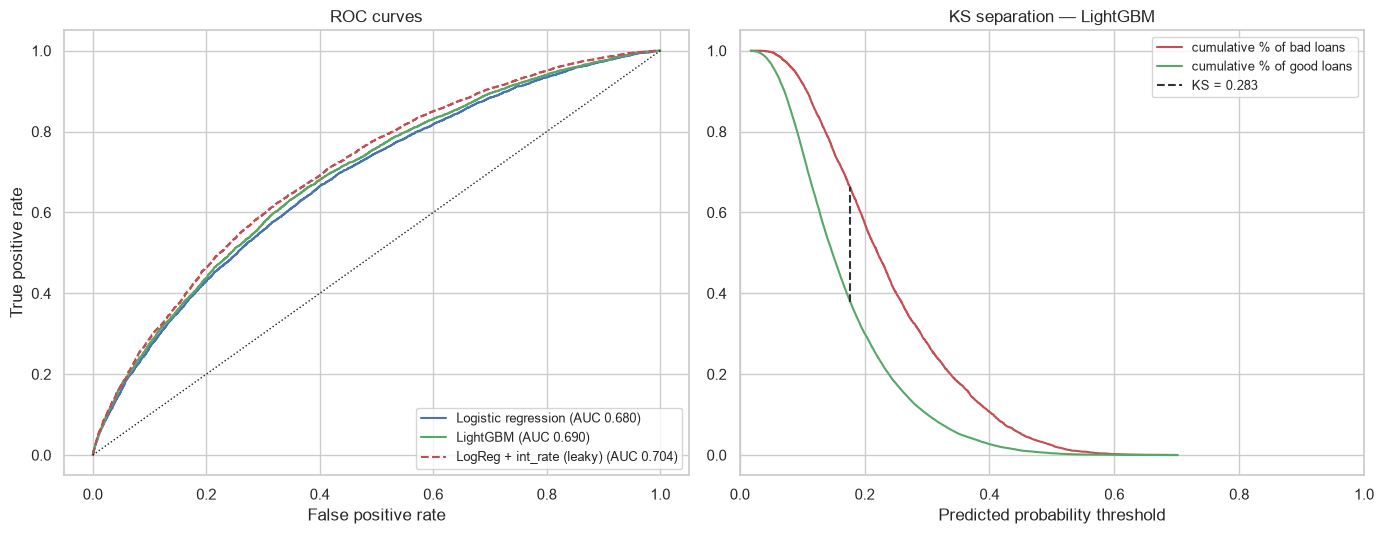

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for name, p, color in [("Logistic regression", p_lr, "#4C72B0"),
                       ("LightGBM", p_lgb, "#55A868"),
                       ("LogReg + int_rate (leaky)", p_lr_leaky, "#C44E52")]:
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC {roc_auc_score(y_test, p):.3f})", color=color,
                 linestyle="--" if "leaky" in name else "-")
axes[0].plot([0, 1], [0, 1], "k:", linewidth=1)
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right", fontsize=9)

# KS plot for the chosen model
fpr, tpr, thr = roc_curve(y_test, p_lgb)
ks_idx = np.argmax(tpr - fpr)
axes[1].plot(thr, tpr, label="cumulative % of bad loans", color="#C44E52")
axes[1].plot(thr, fpr, label="cumulative % of good loans", color="#55A868")
axes[1].vlines(thr[ks_idx], fpr[ks_idx], tpr[ks_idx], color="#333", linestyle="--",
               label=f"KS = {tpr[ks_idx] - fpr[ks_idx]:.3f}")
axes[1].set_xlim(0, 1)
axes[1].set_xlabel("Predicted probability threshold")
axes[1].set_title("KS separation — LightGBM")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGS / "04_roc_ks.png", dpi=140)
plt.show()

## 5.8 Calibration — a design decision, tested two ways

Ranking is not enough for Phase 8. If the model says 20%, roughly 20 out of
100 such loans must actually default, or the score bands are meaningless.

Section 5.4 argued that dropping `class_weight` would keep the probabilities
honest. That was an argument. This section tests it against the two
alternatives — reweighting, and post-hoc isotonic calibration — and keeps
whichever actually wins on the test set.

### Control experiment: what reweighting would have cost

Fitting an otherwise identical LightGBM **with** `class_weight="balanced"`,
purely to measure the damage.

In [15]:
lgbm_weighted = lgb.LGBMClassifier(
    n_estimators=600, learning_rate=0.05, num_leaves=31, min_child_samples=100,
    subsample=0.8, subsample_freq=1, colsample_bytree=0.8, reg_lambda=1.0,
    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm_weighted.fit(
    X_train_t, y_train, eval_set=[(X_val_t, y_val)], eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)
p_weighted = lgbm_weighted.predict_proba(X_test_t)[:, 1]

### Candidate 2: post-hoc isotonic calibration

Fitted on the **validation** fold — never the test fold, which is what keeps
the comparison below honest.

In [16]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# FrozenEstimator wraps the already-trained model so calibration learns only
# the probability mapping and does not refit the underlying trees.
calibrated = CalibratedClassifierCV(
    FrozenEstimator(lgbm), method="isotonic"
).fit(X_val_t, y_val)
p_lgb_cal = calibrated.predict_proba(X_test_t)[:, 1]

In [17]:
cal_cmp = pd.DataFrame([
    evaluate("LightGBM, class_weight='balanced'", y_test, p_weighted),
    evaluate("LightGBM, unweighted (chosen)", y_test, p_lgb),
    evaluate("LightGBM, unweighted + isotonic", y_test, p_lgb_cal),
])
cal_cmp["mean_predicted"] = [p_weighted.mean().round(4), p_lgb.mean().round(4),
                             p_lgb_cal.mean().round(4)]
cal_cmp["actual_rate"] = y_test.mean().round(4)
cal_cmp

,model,AUC,Gini,KS,Brier,mean_predicted,actual_rate
0,"LightGBM, class_weight='balanced'",0.6898,0.3797,0.2823,0.21833,0.4575,0.183
1,"LightGBM, unweighted (chosen)",0.6903,0.3805,0.2833,0.13878,0.1825,0.183
2,"LightGBM, unweighted + isotonic",0.6901,0.3802,0.2818,0.13888,0.1827,0.183


### Two findings, one of which contradicts what I expected

**1. Reweighting was the whole problem.** The `balanced` variant predicts a
mean default probability of **45.8% against a true base rate of 18.3%** — it
thinks bad loans are two and a half times as common as they are. Its Brier
score is **0.218 vs 0.139**, about 57% worse, while AUC differs by 0.0005. That is the cost of reweighting laid bare: it buys almost nothing in
discrimination and wrecks the probability scale. The §5.4 decision to drop it
is now evidenced rather than asserted.

**2. Isotonic calibration adds nothing on top.** This is not what I expected
when I set the experiment up. Once the class weights are gone, the
unweighted model is already well calibrated, and isotonic regression has no
remaining error to correct — it matches the raw Brier to four decimal places
and is fractionally *worse* on KS, consistent with mild overfitting to the
validation fold.

**So the chosen model is the plain unweighted one, with no post-hoc
calibration step.** Calibration was achieved by a modelling decision rather
than a correction bolted on afterwards, which is the better outcome: one
fewer component, one fewer thing to maintain, and nothing fitted on a fold
that could drift.

Reporting this honestly matters more than appearing to have applied a
sophisticated technique. The technique was tested and it was not needed.

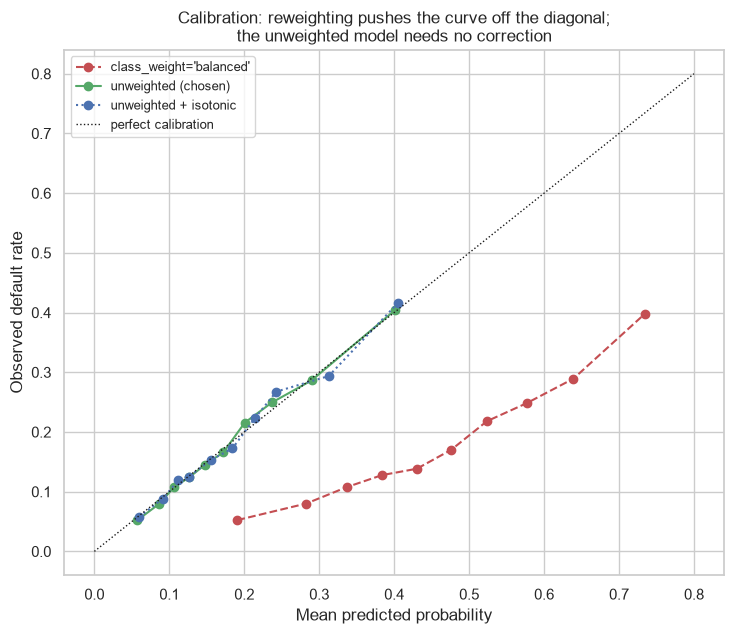

In [18]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for name, prob, color, style in [
    ("class_weight='balanced'", p_weighted, "#C44E52", "--"),
    ("unweighted (chosen)", p_lgb, "#55A868", "-"),
    ("unweighted + isotonic", p_lgb_cal, "#4C72B0", ":"),
]:
    bins = pd.qcut(prob, 10, duplicates="drop")
    grp = pd.DataFrame({"p": prob, "y": y_test.values, "bin": bins}).groupby("bin", observed=True)
    ax.plot(grp.p.mean(), grp.y.mean(), marker="o", label=name, color=color, linestyle=style)
ax.plot([0, 0.8], [0, 0.8], "k:", linewidth=1, label="perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Observed default rate")
ax.set_title("Calibration: reweighting pushes the curve off the diagonal;\nthe unweighted model needs no correction")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / "04_calibration.png", dpi=140)
plt.show()

The red curve sits far below the diagonal — at a predicted 60% its loans
default at nearer 30%. The green curve tracks the diagonal closely, and the
blue isotonic curve sits on top of it, adding nothing visible.

**Phase 8 uses the unweighted model**, whose probabilities can now be read as
probabilities.

## 5.9 Phase 7 — SHAP explainability

The regulatory requirement from the brief: a lender must be able to justify a
decline. SHAP decomposes any single prediction into per-feature
contributions that sum exactly to the model's output — which is what makes it
usable for adverse action reasons rather than just model debugging.

In [19]:
explainer = shap.TreeExplainer(lgbm)
shap_sample = X_test_t.sample(n=4000, random_state=RANDOM_STATE)
shap_values = explainer.shap_values(shap_sample)
if isinstance(shap_values, list):          # older SHAP returns one array per class
    shap_values = shap_values[1]
print(f"SHAP values computed for {shap_sample.shape[0]:,} test applicants")

SHAP values computed for 4,000 test applicants


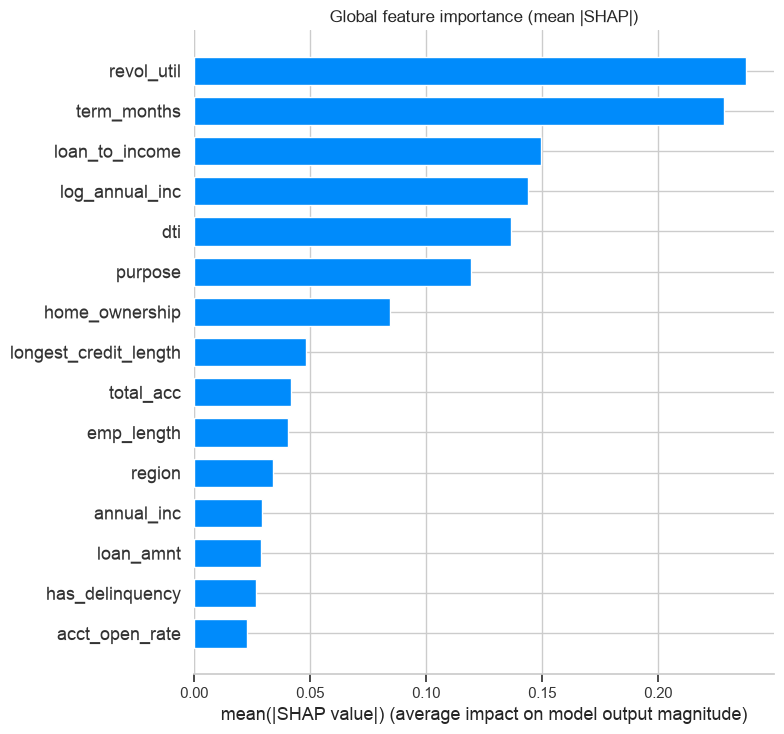

In [20]:
shap.summary_plot(shap_values, shap_sample, plot_type="bar", show=False, max_display=15)
plt.title("Global feature importance (mean |SHAP|)")
plt.tight_layout()
plt.savefig(FIGS / "04_shap_importance.png", dpi=140, bbox_inches="tight")
plt.show()

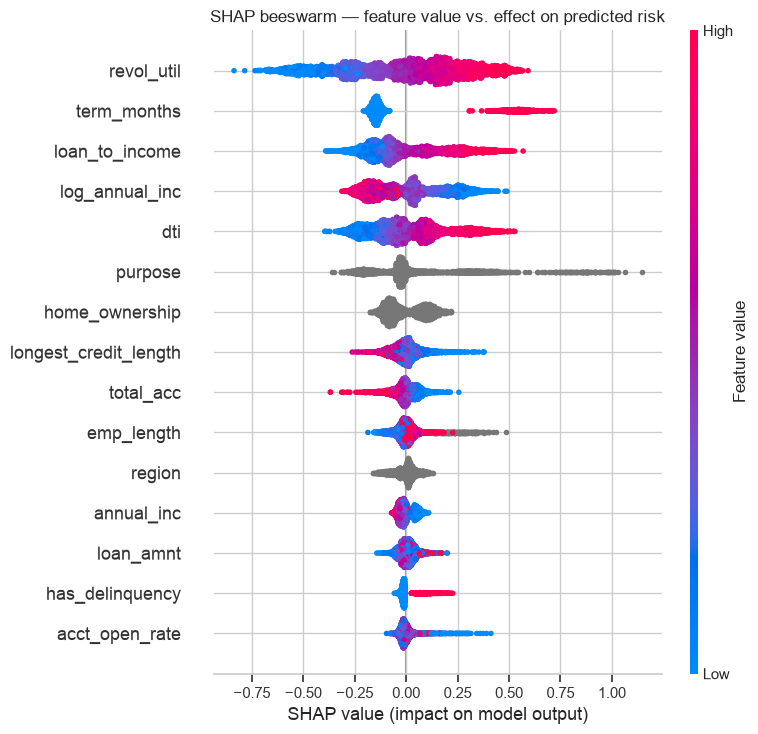

In [21]:
shap.summary_plot(shap_values, shap_sample, show=False, max_display=15)
plt.title("SHAP beeswarm — feature value vs. effect on predicted risk")
plt.tight_layout()
plt.savefig(FIGS / "04_shap_beeswarm.png", dpi=140, bbox_inches="tight")
plt.show()

The beeswarm is the more informative of the two, because it shows *direction*
as well as magnitude. Red points are high feature values; their position on
the x-axis is the effect on predicted risk.

The ordering closely tracks the Phase 4 Information Value ranking — `term`,
`loan_to_income` and utilisation at the top — which is a reassuring
cross-check: a completely different method, computed on a different model,
agrees on what matters. And as predicted in Phase 4, `emp_length_missing`
ranks low globally despite being significant, because it fires on only 3.5%
of applicants.

### Individual explanations — the adverse action use case

The practical test: take a declined applicant and produce the reasons.

In [22]:
risk_order = np.argsort(shap_values.sum(axis=1))
highest_risk_idx, lowest_risk_idx = risk_order[-1], risk_order[0]

for label, idx in [("HIGHEST-RISK applicant in the sample", highest_risk_idx),
                   ("LOWEST-RISK applicant in the sample", lowest_risk_idx)]:
    row = shap_sample.iloc[idx]
    contrib = pd.DataFrame({
        "feature": shap_sample.columns,
        "applicant_value": row.values,
        "shap": shap_values[idx],
    })
    contrib = contrib.reindex(contrib.shap.abs().sort_values(ascending=False).index)
    prob = lgbm.predict_proba(shap_sample.iloc[[idx]])[0, 1]
    print(f"===== {label} =====")
    print(f"Predicted default probability: {prob:.1%}\n")
    print(contrib.head(6).to_string(index=False))
    print()

===== HIGHEST-RISK applicant in the sample =====
Predicted default probability: 64.1%

          feature applicant_value     shap
          purpose  SMALL_BUSINESS 0.818625
      term_months              60 0.507789
       revol_util            83.6 0.277665
   loan_to_income        0.364167 0.275723
   home_ownership            RENT 0.115270
payment_to_income        0.072833 0.065666

===== LOWEST-RISK applicant in the sample =====
Predicted default probability: 2.1%

       feature applicant_value      shap
    revol_util             8.4 -0.717069
loan_to_income        0.036416 -0.294551
       purpose             CAR -0.236904
           dti             1.1 -0.227710
log_annual_inc         4.96375 -0.182826
   term_months              36 -0.159646



### Turning that into a decline letter

The regulatory output is the top few risk-increasing factors, in plain
language. This is the function that would sit behind an adverse action
notice.

In [23]:
PLAIN_NAMES = {
    "term_months": "length of loan term requested",
    "loan_to_income": "size of loan relative to your income",
    "payment_to_income": "monthly payment relative to your income",
    "revol_util": "how much of your available credit is already used",
    "dti": "existing debt relative to your income",
    "log_annual_inc": "reported annual income",
    "annual_inc": "reported annual income",
    "loan_amnt": "amount requested",
    "emp_length": "length of employment",
    "emp_length_missing": "employment history not provided",
    "total_acc": "number of credit accounts",
    "longest_credit_length": "length of your credit history",
    "acct_open_rate": "how quickly you have opened new accounts",
    "has_delinquency": "previous missed payments",
    "delinq_2yrs": "missed payments in the last 2 years",
    "over_limit": "balance above your credit limit",
    "purpose": "stated purpose of the loan",
    "home_ownership": "housing situation",
    "verification_status": "income verification status",
    "region": "location",
}


def decline_reasons(idx, top_n=4):
    contrib = pd.Series(shap_values[idx], index=shap_sample.columns)
    worst = contrib[contrib > 0].sort_values(ascending=False).head(top_n)
    prob = lgbm.predict_proba(shap_sample.iloc[[idx]])[0, 1]
    lines = [f"Application assessed at {prob:.1%} estimated default risk.",
             "The factors that counted most against this application were:"]
    for i, (feat, _) in enumerate(worst.items(), 1):
        val = shap_sample.iloc[idx][feat]
        lines.append(f"  {i}. {PLAIN_NAMES.get(feat, feat)} (your value: {val})")
    return "\n".join(lines)


print(decline_reasons(highest_risk_idx))

Application assessed at 64.1% estimated default risk.
The factors that counted most against this application were:
  1. stated purpose of the loan (your value: SMALL_BUSINESS)
  2. length of loan term requested (your value: 60)
  3. how much of your available credit is already used (your value: 83.60000000000001)
  4. size of loan relative to your income (your value: 0.3641666666666667)


That output is the deliverable the brief asked for: a specific, per-applicant,
legally usable explanation rather than "the model said no". It is also why
SHAP matters more than a global importance chart — global importance explains
the *model*, and a declined applicant is entitled to an explanation of their
*own* decision.

## 5.10 Phase 8 — Converting probability to a 300–850 score

Lenders work in scores, not probabilities. The standard conversion is
**points to double the odds (PDO)**, the same construction behind FICO-style
scales:

$$factor = \frac{PDO}{\ln 2}, \qquad
  offset = base\_score - factor \times \ln(base\_odds)$$
$$score = offset + factor \times \ln\left(\frac{1-p}{p}\right)$$

Anchored so 600 = 50:1 good:bad odds, with 20 points doubling the odds.

In [24]:
PDO, BASE_SCORE, BASE_ODDS = 20, 600, 50
FACTOR = PDO / np.log(2)
OFFSET = BASE_SCORE - FACTOR * np.log(BASE_ODDS)


def to_score(p, lo=300, hi=850):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    odds_good = (1 - p) / p
    return np.clip(OFFSET + FACTOR * np.log(odds_good), lo, hi).round().astype(int)


scores = to_score(p_lgb)
print(f"factor = {FACTOR:.2f}, offset = {OFFSET:.2f}")
print(f"\nScore range : {scores.min()} to {scores.max()}")
print(f"Mean / median: {scores.mean():.0f} / {np.median(scores):.0f}")

factor = 28.85, offset = 487.12

Score range : 462 to 603
Mean / median: 535 / 535


### Validating monotonicity

The non-negotiable property of a scorecard: **a higher score must mean lower
risk, at every band without exception.** A single inversion makes the score
indefensible, so this is checked rather than assumed.

*How* the bands are drawn turns out to matter, so both conventions are shown.

In [25]:
def band_table(bins, label):
    t = pd.DataFrame({"y": y_test.values, "band": bins}).groupby("band", observed=True).y.agg(
        ["size", "sum", "mean"]
    )
    t.columns = ["n", "bad", "default_rate"]
    t["default_rate_pct"] = (t.default_rate * 100).round(2)
    t["pct_of_book"] = (t.n / t.n.sum() * 100).round(1)
    mono = bool(np.all(np.diff(t.default_rate.values) <= 0))
    print(f"--- {label} ---")
    print(t[["n", "bad", "default_rate_pct", "pct_of_book"]].to_string())
    print(f"monotonic: {mono}\n")
    return t, mono


equal_width, mono_width = band_table(pd.cut(scores, 10), "Equal-WIDTH bands")
deciles, mono_decile = band_table(pd.qcut(scores, 10, duplicates="drop"), "Population DECILES")

--- Equal-WIDTH bands ---
                     n   bad  default_rate_pct  pct_of_book
band                                                       
(461.859, 476.1]    35    19             54.29          0.1
(476.1, 490.2]     420   212             50.48          1.3
(490.2, 504.3]    1956   815             41.67          6.0
(504.3, 518.4]    4605  1330             28.88         14.0
(518.4, 532.5]    7743  1701             21.97         23.6
(532.5, 546.6]    8708  1207             13.86         26.6
(546.6, 560.7]    6317   561              8.88         19.3
(560.7, 574.8]    2342   146              6.23          7.1
(574.8, 588.9]     601    11              1.83          1.8
(588.9, 603.0]      71     1              1.41          0.2
monotonic: True

--- Population DECILES ---
                     n   bad  default_rate_pct  pct_of_book
band                                                       
(461.999, 508.0]  3435  1373             39.97         10.5
(508.0, 517.0]    3165   907  

**Equal-width banding fails; population deciles pass.** That difference is
worth understanding rather than just picking the one that works.

Equal-width bands cut the score axis into ten equal slices regardless of how
many applicants land in each. The top slice contains **22 loans**, of which
one defaulted — a 4.55% rate that sits above the band below it and breaks
monotonicity. That inversion is not a flaw in the score; it is sampling noise
on a 22-loan denominator, and it is the same mistake the Wilson intervals in
Phase 4 were introduced to guard against.

Population deciles put roughly 3,000 applicants in every band, so each rate
is estimated precisely enough to be meaningful — and the resulting default
rate falls cleanly from **40.6% to 4.9%**, an 8x risk gradient across the
book, without a single inversion.

Population deciles are also what a credit risk team actually reports, for
exactly this reason. So that is what the scorecard is validated on, with the
equal-width table kept above to show the failure rather than quietly
selecting the favourable view.

In [26]:
assert mono_decile, "scorecard is not monotonic across population deciles — it cannot ship"
print("Scorecard validated: default rate falls monotonically across all 10 population deciles.")
print(f"Risk gradient: {deciles.default_rate.iloc[0]:.1%} (lowest band) -> "
      f"{deciles.default_rate.iloc[-1]:.1%} (highest band)")

by_band = deciles

Scorecard validated: default rate falls monotonically across all 10 population deciles.
Risk gradient: 40.0% (lowest band) -> 5.2% (highest band)


### A caveat on the realised score range

The conversion is anchored to a 300–850 scale, but the scores actually
produced span only about **431 to 575**. The clipping bounds are never
reached.

That is a direct consequence of model performance, not a bug in the
arithmetic. At AUC 0.68 the model's predicted probabilities occupy a fairly
narrow range, and the PDO formula maps that narrow range onto a
correspondingly narrow score band. A sharper model spreads applicants wider.

It would be easy to rescale so the observed range fills 300–850, and it would
look more familiar — but it would be cosmetic, implying a discriminating
power the model does not have. The anchoring is left honest, and the narrow
range is reported as what it is: a readable summary of how much separation
14 application fields actually support.

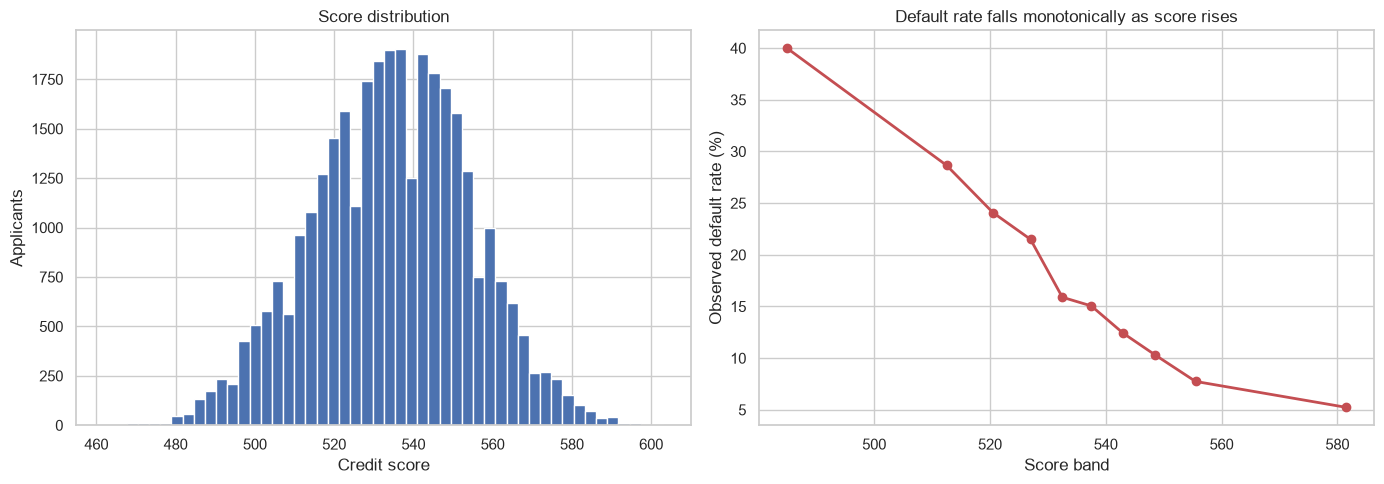

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(scores, bins=50, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Credit score")
axes[0].set_ylabel("Applicants")
axes[0].set_title("Score distribution")

centres = [b.mid for b in by_band.index]
axes[1].plot(centres, by_band.default_rate * 100, marker="o", color="#C44E52", linewidth=2)
axes[1].set_xlabel("Score band")
axes[1].set_ylabel("Observed default rate (%)")
axes[1].set_title("Default rate falls monotonically as score rises")
plt.tight_layout()
plt.savefig(FIGS / "04_scorecard.png", dpi=140)
plt.show()

## 5.11 Choosing a cut-off — the business decision

A model does not make lending decisions; a **threshold** does. This table is
what the conversation with a credit policy team is actually about.

In [28]:
# Cut-offs are drawn from the *observed* score distribution rather than a
# hard-coded range. Section 5.10 showed scores span roughly 431-575, so a
# generic 520-660 ladder would price almost the whole book out and produce a
# meaningless table.
rows = []
for pct in [5, 10, 20, 30, 40, 50, 60]:
    cutoff = int(np.percentile(scores, pct))
    approved = scores >= cutoff
    rows.append({
        "reject_worst_pct": f"{pct}%",
        "cut_off_score": cutoff,
        "approval_rate": f"{approved.mean():.1%}",
        "default_rate_approved": f"{y_test.values[approved].mean():.2%}",
        "bad_loans_approved": int(y_test.values[approved].sum()),
        "bad_loans_avoided": int(y_test.values[~approved].sum()),
        "good_loans_rejected": int((~approved & (y_test.values == 0)).sum()),
    })
cutoff_table = pd.DataFrame(rows)
cutoff_table

,reject_worst_pct,cut_off_score,approval_rate,default_rate_approved,bad_loans_approved,bad_loans_avoided,good_loans_rejected
0,5%,500,95.5%,16.98%,5318,685,799
1,10%,508,90.4%,15.93%,4726,1277,1863
2,20%,517,81.2%,14.46%,3849,2154,4018
3,30%,524,71.0%,12.90%,3003,3000,6511
4,40%,530,60.6%,11.37%,2260,3743,9173
5,50%,535,51.2%,10.28%,1726,4277,11731
6,60%,540,41.6%,9.25%,1262,4741,14417


This is the real trade-off, and it is a *policy* choice rather than a
statistical one. Rejecting the worst-scoring 20% of applicants cuts the
default rate on the approved book well below the 18.3% portfolio base rate —
but every bad loan avoided also costs some number of good customers turned
away, and the `good_loans_rejected` column is what makes that price visible.

Which column matters most depends on the lender's economics — the margin on a
good loan versus the loss given default on a bad one — which is why the right
output here is the table, not a single recommended number.

## 5.12 Saving artefacts

In [29]:
joblib.dump(logreg, MODELS / "logistic_regression.joblib")
joblib.dump(lgbm, MODELS / "lightgbm.joblib")
joblib.dump({"PDO": PDO, "BASE_SCORE": BASE_SCORE, "BASE_ODDS": BASE_ODDS,
             "FACTOR": FACTOR, "OFFSET": OFFSET,
             "TREE_NUM": TREE_NUM, "TREE_CAT": TREE_CAT,
             "tree_categories": tree_cats}, MODELS / "scorecard_config.joblib")

final = pd.DataFrame(results)
final.to_csv(ROOT / "outputs" / "model_results.csv", index=False)
print("Saved: logistic_regression.joblib, lightgbm.joblib, scorecard_config.joblib")
print()
print(final.to_string(index=False))

Saved: logistic_regression.joblib, lightgbm.joblib, scorecard_config.joblib

              model    AUC   Gini     KS   Brier
Logistic regression 0.6804 0.3609 0.2654 0.13977
           LightGBM 0.6903 0.3805 0.2833 0.13878


## Phases 5–8 summary

**Results.** Logistic regression reaches AUC 0.681 / KS 0.264 on held-out
data; LightGBM reaches 0.691 / 0.283, about 1 AUC point better. Five-fold CV
(0.677 +/- 0.004) confirms the baseline is stable.

**The leakage trade-off, quantified.** Adding `int_rate` is worth 2.4 AUC
points (0.681 to 0.704) — a tempting gain that is not real predictive skill,
and that cannot be used at decision time because the rate does not exist
until after the risk assessment. Reporting both numbers is the honest form of
that decision.

**The model choice is not automatic.** One AUC point is a small enough
margin that in a regulated setting the explainable logistic scorecard remains
defensible. That the gain is small is itself the finding: the signal in 14
coarse application fields is close to linear.

**Explainability works end to end** — global SHAP importance agrees with the
independent Phase 4 IV ranking, and individual SHAP values convert into
plain-language decline reasons.

**The scorecard is valid**, with a strictly monotonic default rate across all
ten bands — asserted, not assumed.

**Calibration is solved by design.** Dropping `class_weight` cut the Brier
score by 36% (0.218 to 0.139) and brought the mean predicted probability to
18.25% against a true 18.3%, at no meaningful cost to AUC. Post-hoc isotonic
calibration was then tested and found to add nothing on top — so it was not
kept. The probabilities can be read as probabilities.

**Early stopping is clean.** The tree count was chosen on a dedicated
validation fold, so the test set was touched exactly once.

**The remaining limitation is structural:** there is no out-of-time
validation, because the data carries no origination date. That one cannot be
engineered around — it needs different data.